## Loan approval 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
## data

df = pd.read_csv("Data/loan_approval_dataset.csv")

In [5]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
df.isna().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [11]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [31]:

def rename_cols(df):
    cols =[]
    for i in df.columns:
        cols.append(i.strip())
        # print(i)
    return cols

In [32]:
df.columns=  rename_cols(df)

In [33]:
df["loan_status"]

0        Approved
1        Rejected
2        Rejected
3        Rejected
4        Rejected
          ...    
4264     Rejected
4265     Approved
4266     Rejected
4267     Approved
4268     Approved
Name: loan_status, Length: 4269, dtype: object

In [143]:
df1=  pd.get_dummies(df, columns=['loan_status', 'education','self_employed'], dtype=int)

In [144]:
df1

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status_ Approved,loan_status_ Rejected,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,0,1,0,1,0
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,1,0,1,0,1
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,1,1,0,1,0
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,1,1,0,1,0
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,1000000,2300000,12,317,2800000,500000,3300000,800000,0,1,1,0,0,1
4265,4266,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,0,0,1,0,1
4266,4267,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,1,0,1,1,0
4267,4268,1,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,0,0,1,1,0


In [64]:
df1.drop(['loan_status_ Rejected','education_ Not Graduate','self_employed_ Yes'],axis=1,inplace=True)

In [65]:
df1.rename({"loan_status_ Approved":"loan_status","education_Graduate":"education","self_employed_ No":"self_employed"}, axis='columns', inplace=True)

In [66]:
df1

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Graduate,self_employed
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,1,1
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0,0
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,1,1
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,1,1
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,1000000,2300000,12,317,2800000,500000,3300000,800000,0,1,0
4265,4266,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,0,0
4266,4267,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,0,1
4267,4268,1,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,0,1


In [67]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   income_annum              4269 non-null   int64
 3   loan_amount               4269 non-null   int64
 4   loan_term                 4269 non-null   int64
 5   cibil_score               4269 non-null   int64
 6   residential_assets_value  4269 non-null   int64
 7   commercial_assets_value   4269 non-null   int64
 8   luxury_assets_value       4269 non-null   int64
 9   bank_asset_value          4269 non-null   int64
 10  loan_status               4269 non-null   int32
 11  education_ Graduate       4269 non-null   int32
 12  self_employed             4269 non-null   int32
dtypes: int32(3), int64(10)
memory usage: 383.7 KB


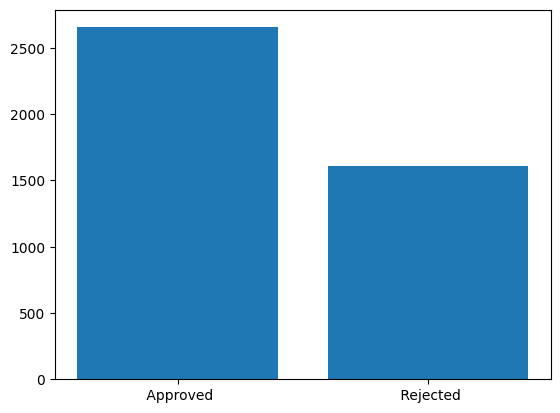

In [91]:
counts = df['loan_status'].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.show()

In [73]:
X = df1.drop(columns=['loan_status'])
y = df1['loan_status']

In [119]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [120]:

X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((3415, 12), (854, 12), (3415,), (854,))

In [121]:
from sklearn.preprocessing import StandardScaler

In [122]:
std_sclr = StandardScaler()

In [123]:
X_train_std=  std_sclr.fit_transform(X_train)
X_test_std= std_sclr.transform(X_test)

In [124]:
log_clf = LogisticRegression()

In [125]:
log_clf.fit(X_train_std,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [126]:
y_train_preds = log_clf.predict(X_train_std)

In [127]:
y_train_preds

array([1, 1, 1, ..., 1, 0, 0])

In [128]:
train_acc  = accuracy_score(y_train,y_train_preds)

In [129]:
train_acc

0.9177159590043924

In [130]:
y_test_preds = log_clf.predict(X_test_std)

In [131]:
y_test_preds

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,

In [132]:
test_acc  = accuracy_score(y_test,y_test_preds)

In [134]:
test_acc

0.9133489461358314

In [141]:
y_pred_1 = log_clf.predict([X_test_std[0]])

In [145]:
y_pred_1

array([1])

In [140]:
classes = df['loan_status'].unique()

In [146]:
classes

array([' Approved', ' Rejected'], dtype=object)

In [142]:
classes[y_pred_1]

array([' Rejected'], dtype=object)